### General Feed Forward Network 

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import random

In [3]:
labels = []
numbers = []

with open(os.path.join(os.getcwd(), 'data/MNISTnumLabels5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        labels.append(int(line))

with open(os.path.join(os.getcwd(), 'data/MNISTnumImages5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        ind_line = line.split('\t')
        ind_line = [float(i) for i in ind_line]

        numbers.append(ind_line)
    

labels = np.array(labels)
numbers = np.array(numbers)

9


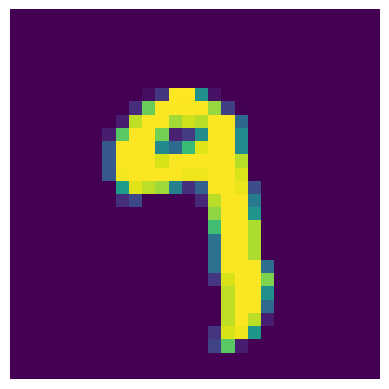

In [4]:
index = random.randint(0, 4999)

example_number = numbers[index]
example_label = labels[index]
matrix = example_number.reshape(28, 28).T

print(example_label)
plt.imshow(matrix)
plt.axis('off')
plt.show()

In [5]:
train_set = []
train_labels = []

test_set = []
test_labels = []

digits = {d: 0 for d in range(0, 10)}

for i in range(len(numbers)):
    label = labels[i]  # get the digit for this image
    
    if label in digits and digits[label] < 400:
        train_set.append(numbers[i])
        train_labels.append(label)
        digits[label] += 1
    else:
        test_set.append(numbers[i])
        test_labels.append(label)
        digits[label] += 1


train_set = np.array(train_set)
test_set = np.array(test_set)
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)
# normalizing the datasets
train_set = train_set.astype(np.float32)/255.0
test_set = test_set.astype(np.float32)/255.0

combined_train_data = list(zip(train_labels, train_set))
random.shuffle(combined_train_data)

combined_test_data = list(zip(test_labels, test_set))
random.shuffle(combined_test_data)

print(len(combined_train_data), len(combined_test_data))

4000 1000


In [6]:
m, n = train_set.shape

X_train, X_test = train_set, test_set
Y_train, Y_test = train_labels, test_labels

_, m_train = X_train.shape
_, m_test = X_test.shape

In [7]:
# Shuffle training set
perm_train = np.random.permutation(X_train.shape[0])  # columns = samples
X_train = X_train[perm_train]
Y_train = np.array(Y_train)[perm_train]  

# Shuffle test set
perm_test = np.random.permutation(X_test.shape[0])
X_test = X_test[perm_test]
Y_test = np.array(Y_test)[perm_test]

X_train.shape, Y_train.shape

((4000, 784), (4000,))

### Neural Network Implementation

In [8]:
class CustomNeuralNet:

    def __init__(self, layers, layer_sizes, momentum=0.9):
        self.layers = layers
        self.layer_sizes = layer_sizes
        self.momentum = momentum

        self.W = []
        self.b = []
        self.vW = []
        self.vb = []

        self.train_accuracy_over_epochs = []
        self.test_accuracy_over_epochs = []
        self.train_error_over_epochs = []
        self.test_error_over_epochs = []


        for i in range(self.layers - 1):
            in_size = layer_sizes[i]
            out_size = layer_sizes[i+1]

            W_i = np.random.randn(in_size, out_size) * 0.01
            b_i = np.zeros((1, out_size))

            self.W.append(W_i)
            self.b.append(b_i)

            self.vW.append(np.zeros_like(W_i))
            self.vb.append(np.zeros_like(b_i))

    
    ### Activation Functions
    def tanh(self, x):
        return np.tanh(x)
    
    def tanh_deriv(self, x):
        return 1 - np.tanh(x)**2
    
    ### Forward Pass
    def forward(self, x):
        A = x

        '''
        We store A and Z at every layer so that during backprop we can 
        compute gradients for weights, biases, and previous layers.
        '''
        A_cache = [A]
        Z_cache = []

        for i in range(self.layers - 1):
            Z = A @ self.W[i] + self.b[i]       # linear
            A = self.tanh(Z)                   # activation
            Z_cache.append(Z)
            A_cache.append(A)

        return A, Z_cache, A_cache
    
    ### Back propogation
    def backward(self, Y, Z_cache, A_cache):
        m = Y.size

        # Gradients (derivatives)
        dW = [None] * (self.layers - 1)
        db = [None] * (self.layers - 1)

        # Derivative of MSE wrt output activation
        A_final = A_cache[-1]

        if Y.ndim == 1 or Y.shape[1] == 1:
            Y_onehot = np.zeros_like(A_cache[-1])
            Y_onehot[np.arange(len(Y)), Y] = 1
            Y = Y_onehot

        dA = (A_final - Y) * (self.tanh_deriv(Z_cache[-1]))

        # Backprop layer by layer
        for i in reversed(range(self.layers - 1)):
            A_prev = A_cache[i]

            dW[i] = (A_prev.T @ dA) / m
            db[i] = np.sum(dA, axis=0, keepdims=True) / m

            if i > 0:
                dA = (dA @ self.W[i].T) * self.tanh_deriv(Z_cache[i-1])

        return dW, db
    
    ### Momentum Update
    def update_params(self, dW, db, lr):
        for i in range(self.layers - 1):

            # update momentum buffers
            self.vW[i] = self.momentum * self.vW[i] - lr * dW[i]
            self.vb[i] = self.momentum * self.vb[i] - lr * db[i]

            # update parameters
            self.W[i] += self.vW[i]
            self.b[i] += self.vb[i]

    ### Model Training
    def train(self, X, Y, X_test, Y_test, epochs, lr, batch_size=64):
        n = X.shape[0]   # number of samples

        for epoch in range(epochs):

            perm = np.random.permutation(n)
            X = X[perm]
            Y = Y[perm]

            for i in range(0, n, batch_size):
                X_batch = np.array(X[i:i+batch_size])
                Y_batch = np.array(Y[i:i+batch_size])

                # Forward on this batch only
                A, Z_cache, A_cache = self.forward(X_batch)

                # Backprop on this batch only
                dW, db = self.backward(Y_batch, Z_cache, A_cache)

                # Update
                self.update_params(dW, db, lr)

            if epoch % 10 == 0:
                acc = self.accuracy(X, Y)
                acc2 = self.accuracy(X_test, Y_test)

                self.train_accuracy_over_epochs.append(acc)
                self.test_accuracy_over_epochs.append(acc2)

                self.train_error_over_epochs.append(1 - acc)
                self.test_error_over_epochs.append(1 - acc2)
                print(f"Epoch {epoch} | Accuracy: {acc:.4f}")


    def predict(self, X, show=False):
        A, _, _ = self.forward(X)
        result= np.argmax(A, axis=1)
        if show:
            plt.imshow(X.reshape(28,28).T)
            plt.axis('off')
            plt.show()

        return result

    def visualize_features(self, neuron_indices=None, num_features=20):
        """
        Visualize features learned by hidden neurons.
        Each hidden neuron's weights form a 28x28 image.
        """
        if neuron_indices is None:
            # Randomly select neurons
            num_hidden = self.layer_sizes[1]
            neuron_indices = np.random.choice(num_hidden, num_features, replace=False)
        
        # Get weights from input to hidden layer (first layer)
        W_hidden = self.W[0]  # Shape: (784, num_hidden)
        
        fig, axes = plt.subplots(4, 5, figsize=(10, 8))
        fig.suptitle("Features Learned by Hidden Neurons")
        
        for idx, neuron_idx in enumerate(neuron_indices):
            row = idx // 5
            col = idx % 5
            
            # Get weights for this neuron
            weights = W_hidden[:, neuron_idx]
            
            # Normalize for visualization
            weights_normalized = (weights - weights.min()) / (weights.max() - weights.min() + 1e-8)
            
            # Reshape to 28x28
            feature_image = weights_normalized.reshape(28, 28).T
            
            axes[row, col].imshow(feature_image, cmap='gray')
            axes[row, col].axis('off')
            axes[row, col].set_title(f'N{neuron_idx}', fontsize=8)
        
        plt.tight_layout()
        plt.show()
        
        return neuron_indices

    def accuracy(self, X, Y_onehot):
        predictions = self.predict(X)
        return np.mean(predictions == Y_onehot)

    def plot_accuracy_over_epochs(self):
        epochs = list(range(len(self.train_accuracy_over_epochs)))

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, self.train_accuracy_over_epochs, label="Train Accuracy")
        plt.plot(epochs, self.test_accuracy_over_epochs, label="Test Accuracy")

        plt.title("Accuracy Over Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")

        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        plt.show()

    def plot_error_over_epochs(self):
        epochs = np.arange(len(self.train_error_over_epochs))

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, self.train_error_over_epochs, label="Training Error")
        plt.plot(epochs, self.test_error_over_epochs, label="Test Error")

        plt.title("Error Fraction Over Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Error Fraction")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def confusion_matrix(self, X, Y):
        num_classes = self.layer_sizes[-1]   # should be 10 for MNIST
        cm = np.zeros((num_classes, num_classes), dtype=int)

        predictions = self.predict(X)  # shape (m,)
        
        for true, pred in zip(Y, predictions):
            cm[int(true), int(pred)] += 1

        return cm


### Applying the nn on the dataset

In [9]:
nn = CustomNeuralNet(layers=3, layer_sizes=[784, 128, 10])

nn.train(X=X_train, Y=Y_train, X_test=X_test, Y_test=Y_test, epochs=5000, lr=0.01, batch_size=100)

Epoch 0 | Accuracy: 0.1000
Epoch 10 | Accuracy: 0.1003
Epoch 20 | Accuracy: 0.1000
Epoch 30 | Accuracy: 0.1000
Epoch 40 | Accuracy: 0.1000
Epoch 50 | Accuracy: 0.1000
Epoch 60 | Accuracy: 0.1000
Epoch 70 | Accuracy: 0.1000
Epoch 80 | Accuracy: 0.1000
Epoch 90 | Accuracy: 0.1000
Epoch 100 | Accuracy: 0.1588
Epoch 110 | Accuracy: 0.1000
Epoch 120 | Accuracy: 0.1000
Epoch 130 | Accuracy: 0.1000
Epoch 140 | Accuracy: 0.1305
Epoch 150 | Accuracy: 0.1000
Epoch 160 | Accuracy: 0.1000
Epoch 170 | Accuracy: 0.1000
Epoch 180 | Accuracy: 0.1000
Epoch 190 | Accuracy: 0.2147
Epoch 200 | Accuracy: 0.2800
Epoch 210 | Accuracy: 0.1847
Epoch 220 | Accuracy: 0.2955
Epoch 230 | Accuracy: 0.2617
Epoch 240 | Accuracy: 0.1005
Epoch 250 | Accuracy: 0.2457
Epoch 260 | Accuracy: 0.2717
Epoch 270 | Accuracy: 0.2218
Epoch 280 | Accuracy: 0.1832
Epoch 290 | Accuracy: 0.2585
Epoch 300 | Accuracy: 0.1450
Epoch 310 | Accuracy: 0.3088
Epoch 320 | Accuracy: 0.3513
Epoch 330 | Accuracy: 0.2065
Epoch 340 | Accuracy: 0.3

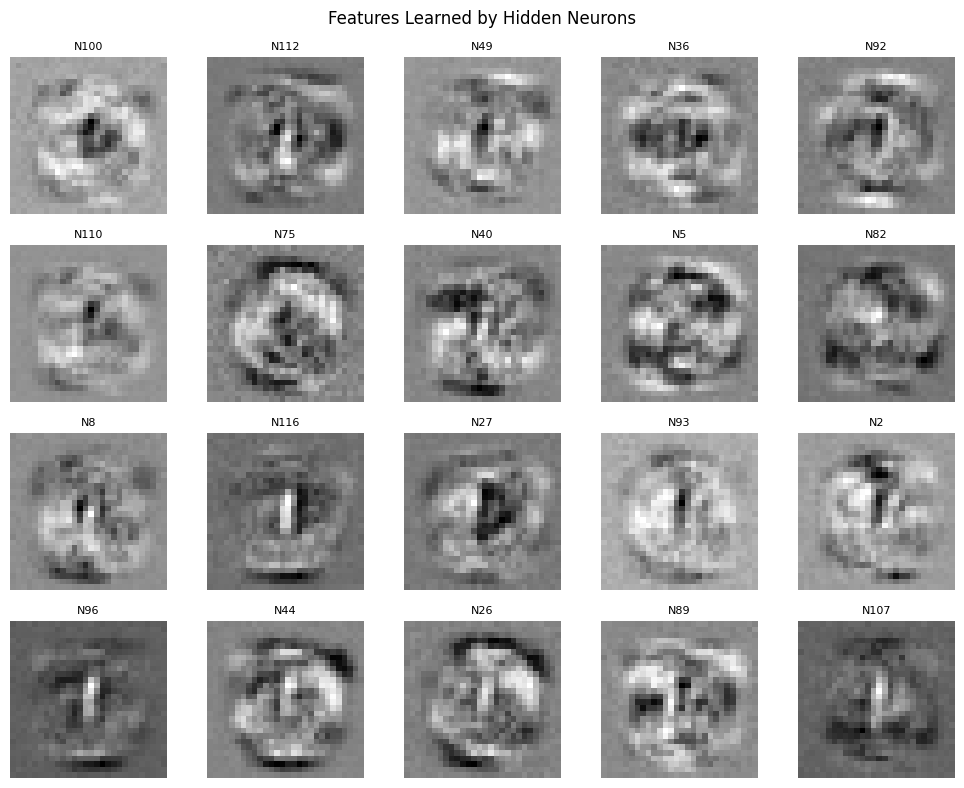

array([100, 112,  49,  36,  92, 110,  75,  40,   5,  82,   8, 116,  27,
        93,   2,  96,  44,  26,  89, 107])

In [11]:
nn.visualize_features()

In [10]:
nn.accuracy(X_test, Y_test)

0.843

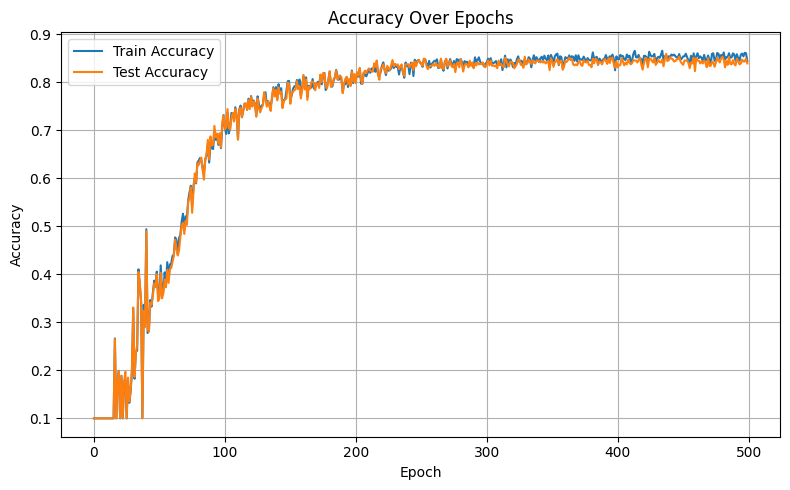

In [127]:
nn.plot_accuracy_over_epochs()

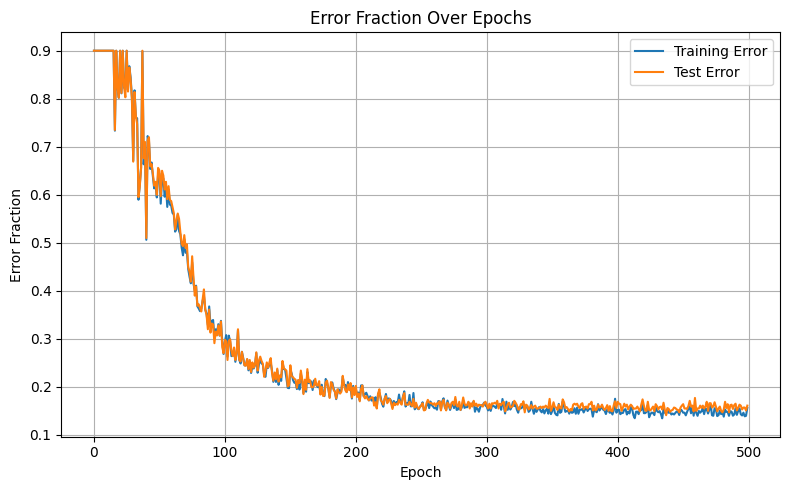

In [128]:
nn.plot_error_over_epochs()

In [129]:
train_cm = nn.confusion_matrix(X_train, Y_train)
test_cm = nn.confusion_matrix(X_test, Y_test)

print("Training Confusion Matrix:\n", train_cm)
print("Test Confusion Matrix:\n", test_cm)

Training Confusion Matrix:
 [[375   0   1   2   1   6   6   2   6   1]
 [  0 378   6   1   1   0   4   1   9   0]
 [  6   4 337   8   2   0   6  17  17   3]
 [  2   3  11 330   2   7   4  19  16   6]
 [  2   5   1   0 313   2   7   6  10  54]
 [ 10   6   1  23   6 285  11  15  38   5]
 [ 10   5   2   1   3   7 368   1   3   0]
 [  3  14   8   2   6   1   2 341   4  19]
 [  5  14   7  12   3   5   7   4 340   3]
 [  4   6   1   6   7   0   1  26  10 339]]
Test Confusion Matrix:
 [[94  0  0  0  0  2  3  0  1  0]
 [ 0 93  2  1  0  0  0  1  2  1]
 [ 2  3 82  3  1  0  1  4  4  0]
 [ 0  0  6 81  0  2  0  4  5  2]
 [ 0  3  1  0 67  0  4  1  2 22]
 [ 3  2  1  3  1 74  2  3 10  1]
 [ 3  0  2  0  0  2 93  0  0  0]
 [ 0  2  3  2  1  0  1 86  0  5]
 [ 1  1  1  3  2  1  4  4 79  4]
 [ 1  1  0  1  3  1  0  7  0 86]]


In [130]:
nn.accuracy(X_train, Y_train)

0.8515

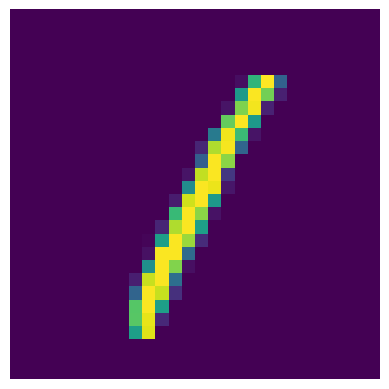

1

In [135]:
index = random.randint(0, 999)
A = nn.predict(X_test[index], show=True)
A[0]

In [136]:
np.savez("model_weights.npz", W1=nn.W[0], b1=nn.b[0], W2=nn.W[1], b2=nn.b[1])

In [137]:
data = np.load("model_weights.npz")
W1_copy = data["W1"]
b1_copy = data["b1"]
W2_copy = data["W2"]
b2_copy = data["b2"]

nn.W[0] == W1_copy

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])